# Jacobian unit-test figures — Test Case F (real LLC4320 grid)

Figures for **Test Case F** of `tests/test_jacobian.py`
(`test_jacobian_real_grid_constant_field_zero_gradient`).

**Idea.** Push a spatially *constant* model velocity field through
`calculate_jacobian` on the real curvilinear LLC4320 grid (true
`CS`/`SN`, real metrics, 13-face `face_connections`) and check the
gradient is essentially zero over the ocean interior.

**The subtlety this notebook makes visible.** The ECCO routine
rotates to geographic axes *before* differencing, so it actually
differentiates `u_lambda = U0·CS − V0·SN`. Where `CS`/`SN` are
locally smooth (most of the ocean) that is constant ⇒ zero
gradient to machine precision. Near grid singularities (the
Arctic-cap face and cube-sphere corners) `grad(CS)` is large, so a
constant field legitimately picks up an apparent gradient there.
Hence the test asserts on the **median** and **99th percentile**,
not the global max.

*Network note:* this notebook needs the real grid. It reuses the
local cache at `tj.REAL_GRID_CACHE` if present, else downloads it
from S3 (multi-GB, a few minutes).

Generated by JXP and Claude

In [1]:
# Imports at top (project convention). We reuse tests/test_jacobian.py so
# the figures are built from the same loader, fixtures and assertions the
# unit test uses.
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import dbof.utils.native_gradient as ng

_REPO = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
_TESTS = os.path.join(_REPO, 'tests')
if _TESTS not in sys.path:
    sys.path.insert(0, _TESTS)

import test_jacobian as tj  # noqa: E402

print('grid cache :', tj.REAL_GRID_CACHE)
print('S3 source  :', tj.REAL_GRID_S3)


grid cache : /tmp/llc4320_grid_cache.nc
S3 source  : {'s3_endpoint': 'https://s3-west.nrp-nautilus.io', 'bucket': 'dbof', 'folder': 'LLC4320'}


## 1. Load the real grid and run the Jacobian on a constant field

We reuse `tj.load_real_llc_grid()` (cached subset of `CS, SN, dxC,
dyC, hFacC`) and `tj.add_constant_velocity()` — the exact code the
test runs.

In [2]:
ds = tj.load_real_llc_grid()
grid = tj.set_xgcm_grid(ds.drop_vars('hFacC'), use_connections=True)
print('grid sizes:', dict(ds.sizes))

# Arbitrary non-zero constant model velocities (their values must not matter).
u_x, v_y = tj.add_constant_velocity(ds, u0=0.5, v0=-0.3)
dudl, dudp, dvdl, dvdp = ng.calculate_jacobian(u_x, v_y, ds, grid)
outputs = [dudl, dudp, dvdl, dvdp]
names = [r'$\partial u_\lambda/\partial \lambda$',
         r'$\partial u_\lambda/\partial \phi$',
         r'$\partial v_\phi/\partial \lambda$',
         r'$\partial v_\phi/\partial \phi$']

# Ocean mask with the face-edge ring trimmed, mirroring the test.
ocean = tj.interior(ds['hFacC']).values > 0
pooled = np.concatenate(
    [np.abs(tj.interior(o).values[ocean]) for o in outputs])
print('ocean-interior points pooled:', pooled.size)
print('median |grad| = %.3e' % np.median(pooled))
print('99th pct |grad| = %.3e' % np.percentile(pooled, 99.0))
print('max  |grad| = %.3e' % pooled.max())


grid sizes: {'face': 13, 'j': 4320, 'i': 4320, 'i_g': 4320, 'j_g': 4320}


ocean-interior points pooled: 560890676


median |grad| = 3.223e-17


99th pct |grad| = 5.024e-07


max  |grad| = 6.693e-04


## 2. Where the gradient is (and isn't) zero

`|du_λ/dλ|` on a *smooth-rotation* face vs. the *Arctic-cap* face,
downsampled for display and land-masked. The smooth face is black
(machine zero) almost everywhere; the cap face lights up where the
grid rotation changes rapidly — the `grad(CS)` term, not a bug.

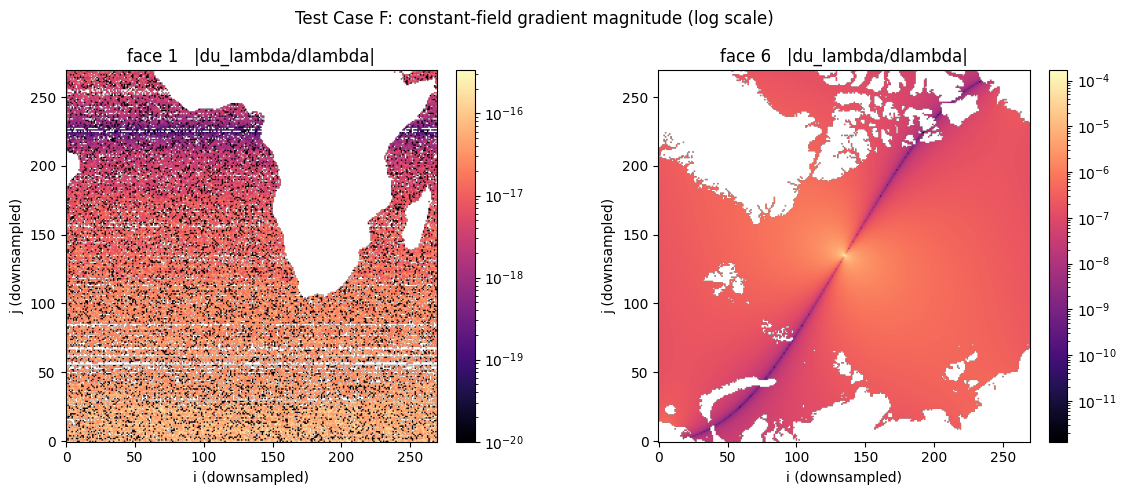

In [3]:
def face_map(da, face, stride=16):
    """Downsampled, land-masked |field| on one face for display."""
    sub = np.abs(da.isel(face=face).values[::stride, ::stride])
    lm = ds['hFacC'].isel(face=face).values[::stride, ::stride] > 0
    out = np.where(lm, sub, np.nan)
    return out

faces_to_show = [1, 6]  # face 1: smooth rotation; face 6: Arctic cap
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, fc in zip(axes, faces_to_show):
    img = face_map(dudl, fc)
    finite = img[np.isfinite(img) & (img > 0)]
    vmin = max(finite.min(), 1e-20) if finite.size else 1e-20
    vmax = finite.max() if finite.size else 1.0
    pcm = ax.imshow(img, origin='lower', cmap='magma',
                    norm=LogNorm(vmin=vmin, vmax=vmax))
    fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title('face %d   |%s|' % (fc, 'du_lambda/dlambda'))
    ax.set_xlabel('i (downsampled)'); ax.set_ylabel('j (downsampled)')
fig.suptitle('Test Case F: constant-field gradient magnitude (log scale)')
fig.tight_layout(); plt.show()


## 3. The distribution the test asserts on

Histogram of pooled ocean-interior `|gradient|` (log scale). The
median sits at machine precision and the 99th percentile is tiny;
both fall far below the test thresholds. The long thin tail to the
right is the handful of singularity points.

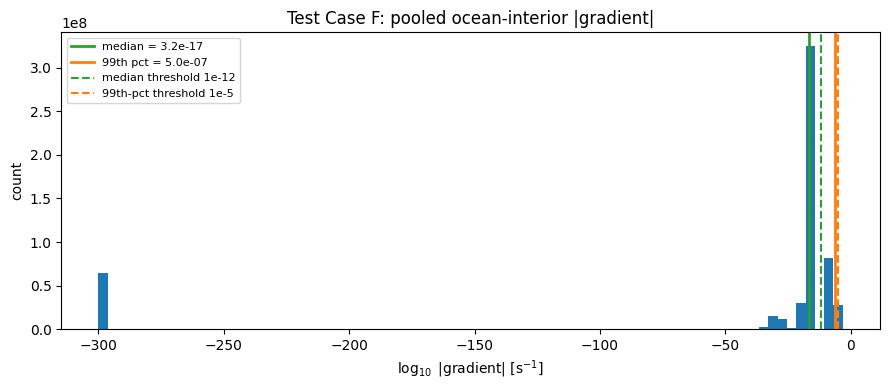

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
logv = np.log10(pooled + 1e-300)
ax.hist(logv, bins=80)
med = np.median(pooled)
p99 = np.percentile(pooled, 99.0)
ax.axvline(np.log10(med + 1e-300), color='C2', lw=2,
           label=f'median = {med:.1e}')
ax.axvline(np.log10(p99), color='C1', lw=2, label=f'99th pct = {p99:.1e}')
ax.axvline(np.log10(1e-12), color='C2', ls='--',
           label='median threshold 1e-12')
ax.axvline(np.log10(1e-5), color='C1', ls='--',
           label='99th-pct threshold 1e-5')
ax.set_xlabel(r'$\log_{10}$ |gradient| [s$^{-1}$]')
ax.set_ylabel('count')
ax.set_title('Test Case F: pooled ocean-interior |gradient|')
ax.legend(fontsize=8); fig.tight_layout(); plt.show()


## 4. Which faces carry the curvature term

Per-face median vs. max of `|du_λ/dλ|` over the ocean interior. The
medians are uniformly at machine precision; only a few faces (the
Arctic cap and its neighbours) show a large max.

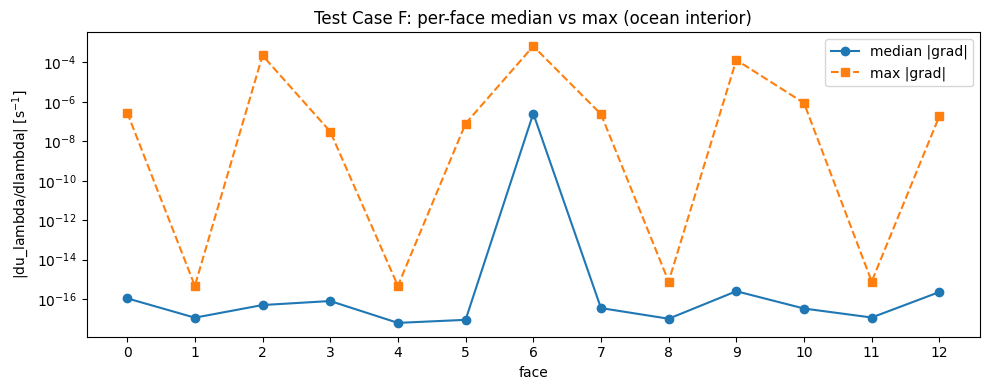

In [5]:
nf = ds.sizes['face']
fmed, fmax = [], []
for fc in range(nf):
    om = tj.interior(ds['hFacC']).isel(face=fc).values > 0
    v = np.abs(tj.interior(dudl).isel(face=fc).values[om])
    fmed.append(np.median(v) if v.size else np.nan)
    fmax.append(v.max() if v.size else np.nan)

x = np.arange(nf)
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(x, np.array(fmed) + 1e-300, 'o-', label='median |grad|')
ax.semilogy(x, np.array(fmax) + 1e-300, 's--', label='max |grad|')
ax.set_xticks(x)
ax.set_xlabel('face'); ax.set_ylabel('|du_lambda/dlambda| [s$^{-1}$]')
ax.set_title('Test Case F: per-face median vs max (ocean interior)')
ax.legend(); fig.tight_layout(); plt.show()


## 5. Run the actual unit test

Reuses the cached grid; no exception means Test Case F passes.

In [6]:
import os
os.environ['RUN_LLC_NETWORK_TESTS'] = '1'  # opt in (cache already present)
tj.test_jacobian_real_grid_constant_field_zero_gradient()
print('Test Case F passed.')


Test Case F passed.
